# Context

# Where are we?

- Gamma-ray astronomy
    - Very-high-energy domain (VHE; 100 GeV < E < 100 TeV)
    - Imaging Atmospheric Cherenkov Telescopes (IACTs)
    - Water Cherenkov Detectors

The Cherenkov Telescope Array Observatory (CTAO) is the future observatory at VHE gamma rays

![CTAO spectrum](images/Spectrum_CTAO_FINAL.png)

Video about how Imaging Atmospheric Cherenkov Telescopes work: https://www.youtube.com/watch?v=5gRHFQP_SjU


# Introduction

## What is Gammapy?

Gammapy is an open-source Python package for gamma-ray astronomy. It is used as a core library for the Science Analysis tools of the Cherenkov Telescope Array Observatory (CTAO). It is also used in other Imaging Atmospheric Cherenkov Telescope facilities, such as MAGIC, VERITAS, and H.E.S.S. It can also be used by Water Cherenkov Detectors such as HAWC or _Fermi_-LAT analyses.

![Summary Gammapy](images/aa46488-23-fig1.png)

Credit: Donath et al. A&A, 678 (2023) A157.

## The dataset of the hands-on sessions

In the following Jupyter notebooks, we will analyse public data of the standard source at VHE gamma rays, the Crab Nebula. The data used is from the H.E.S.S. Collaboration.

## What is an observation

Each observation consists of ~20 min of data taking. The data that we will use is already processed and ready for scientific analysis.

The data is stored in a "fits" file format. A standard digital file format useful for storage of astronomy data (mostly images, but tables as well)

## Information in each observation

For each observation, the information required to produce scientific results is:

    - Events table
    - Good Time Interval
    - Instrument Response Functions

In [1]:
from astropy.io import fits

filename_1 = 'hess-dl3-dr1/data/hess_dl3_dr1_obs_id_023523.fits.gz'

# Access the fits file with astropy
with fits.open(filename_1) as hdul:
    hdul.info()

Filename: hess-dl3-dr1/data/hess_dl3_dr1_obs_id_023523.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   ()      
  1  EVENTS        1 BinTableHDU     77   7613R x 5C   [1K, 1D, 1E, 1E, 1E]   
  2  GTI           1 BinTableHDU     32   1R x 2C   [1D, 1D]   
  3  AEFF          1 BinTableHDU     47   1R x 5C   [96E, 96E, 6E, 6E, 576E]   
  4  EDISP         1 BinTableHDU     43   1R x 7C   [96E, 96E, 160E, 160E, 6E, 6E, 92160E]   
  5  PSF           1 BinTableHDU     48   1R x 7C   [32E, 32E, 6E, 6E, 144E, 144E, 27648E]   
  6  BKG           1 BinTableHDU     39   1R x 7C   [50E, 50E, 50E, 50E, 20E, 20E, 50000E]   


### Events table

Table with gamma-like events. It contains the following information:
- Trigger (arrival) time
- Reconstructed energy (we do not know the true energy of the events!!)
- Reconstruced event position (we do not know the true energy of the events!!)


In [2]:
from gammapy.data import EventList
events_1 = EventList.read(filename_1)

In [3]:
events_1.table

TIME,ENERGY,RA,DEC,EVENT_ID
,TeV,deg,deg,
Time,float32,float32,float32,int64
53343.92234782471,10.352011,84.97964,23.89347,5407363825684
53343.922348165426,4.0246882,84.54751,21.004095,5407363825695
53343.922354406706,2.2048872,85.39696,19.41868,5407363825831
53343.92236088141,0.69548655,81.93147,20.79867,5407363825970
53343.922366265215,0.86911184,85.98302,21.053099,5407363826067
53343.92236803166,4.1240892,86.97305,21.837437,5407363826095
53343.92236932359,1.6680022,83.40073,19.771587,5407363826128
53343.92237114528,4.7649446,82.25036,19.22003,5407363826168


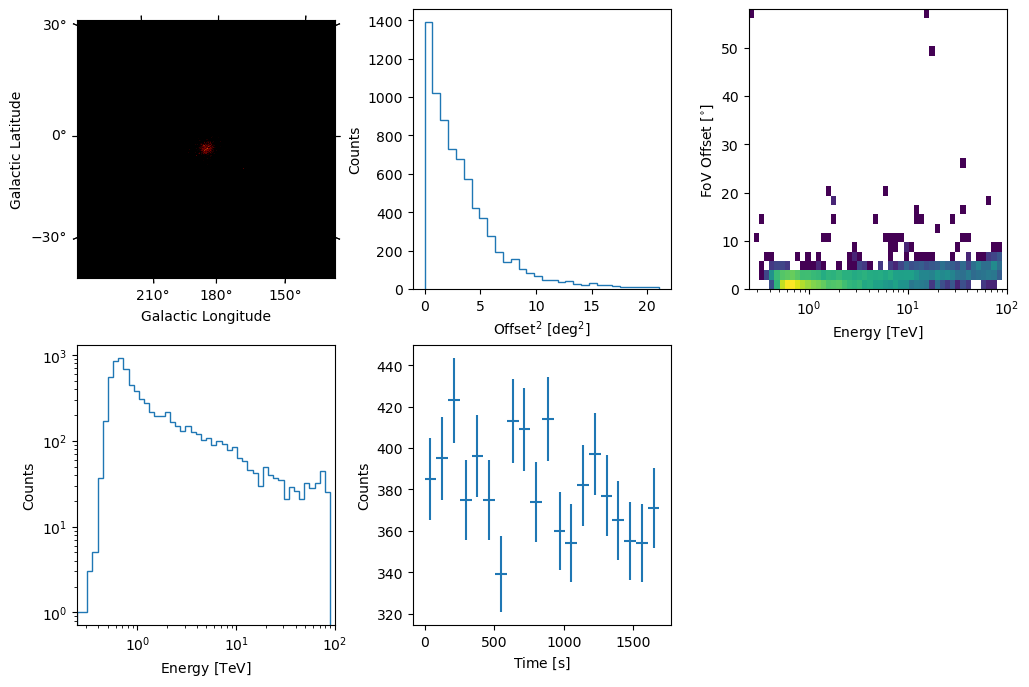

In [4]:
events_1.peek()

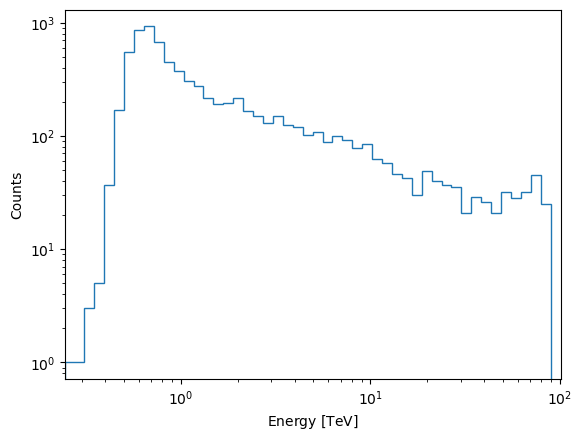

In [5]:
events_1.plot_energy();

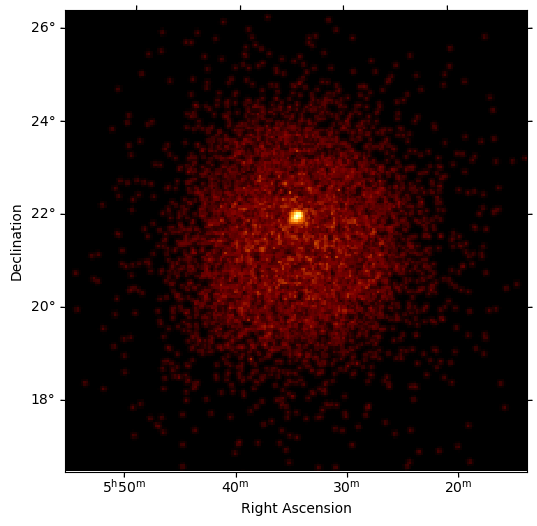

In [6]:
import matplotlib.pyplot as plt
import astropy.units as u
from gammapy.maps import WcsGeom, WcsNDMap

def plot_image(events, ax=None, allsky=False):
    """
    Adapted from `~gammapy.data.EventList.plot_image` to 
    allow plotting on a WCSAxes.

    Quick look counts map sky plot.

    Parameters
    ----------
    ax : `~matplotlib.pyplot.Axes`, optional
        Matplotlib axes.
    allsky :  bool, optional
        Whether to plot on an all sky geom. Default is False.
    """
    m = events._counts_image(allsky=allsky)
    if ax is None:
        fig, ax = plt.subplots(
            1, 1, figsize=(8, 8),
            subplot_kw={"projection":m.geom.wcs}
        )
    else:
        if hasattr(ax, 'wcs'):
            target_geom = WcsGeom(wcs=ax.wcs)
            m = m.interp_to_geom(target_geom)
    m.plot(ax=ax, stretch="sqrt")
        
# Using default WCS geom
# plot_image2(events_1)        

# Using different geom
opts = {
    "width": 10*u.deg,
    "binsz": 0.05,
    "proj": "TAN",
    "frame": "icrs",
    "skydir": events_1._plot_center,
}
m_icrs = WcsNDMap.create(**opts)
fig,ax=plt.subplots(1,1,figsize=(8,6), subplot_kw={"projection":m_icrs.geom.wcs})
plot_image(events_1,ax=ax)

### Instrument Response Functions

It is a characterisation of the telescope performance.

"The instrument response functions (IRFs) provide a mathematical description that links the reconstructed photon arrival direction 𝑝′, energy 𝐸′ and trigger time 𝑡′ of an event to the true incident direction 𝑝, energy 𝐸 and time 𝑡 of a photon."

![IRFs](images/irfs.jpg)

Given the real emission of the source, we indirectly detect the emission through the telescope, which may be more efficient at certain energies than others, with a certain resolution, etc. From the recorded and reconstructed information we obtain, we have to recover the real emission given the telescope performance (IRFs). In optical astronomy, the IRFs would be something like more or less the CCD quantum efficiency, reference stars, etc.

In IACTs, the IRFs are formed by:
- Effective area
- Energy dispersion matrix
- Point spread function

#### Effective area

It is the effective collection area of the detector (unit: $\rm{m}^2$). It is the product of the detector collection area times its detection efficiency at true energy $E_{\rm true}$ and position $p_{\rm true}$.

/Users/aaguasca/anaconda3/envs/gammapy-2.1/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


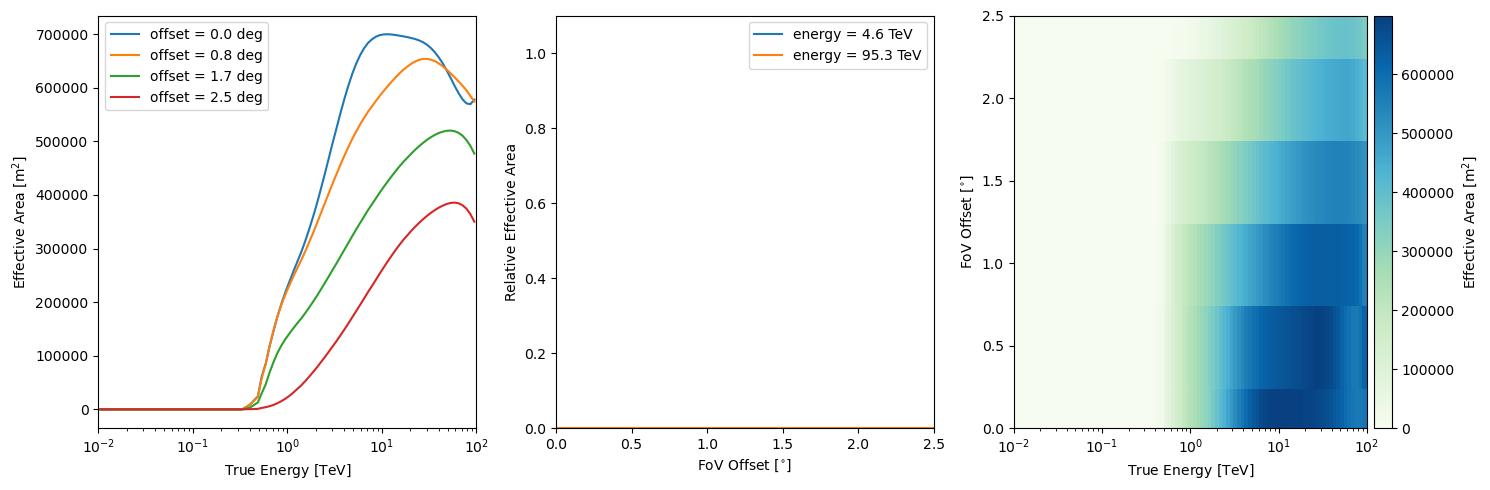

In [7]:
from gammapy.data import DataStore

data_store = DataStore.from_dir("hess-dl3-dr1")
obs = data_store.obs(23523)
obs.aeff.peek()

- The higher the Aeff, the better

Note the large effective area values above 1 TeV of about $50000~\rm m^2$. These values come from the fact that if we place a telescope inside the Cherenkov light pool, we can detect this source. So, our effective area is much larger than the size of the telescope dish!

In [8]:
import math
(500000*u.Unit("m2")/math.pi)**0.5

<Quantity 398.9422804 m>

#### Energy dispersion matrix

It gives the probability of reconstructing the photon at energy $E$ when the true energy is 
$E_{\rm true}$ and the true position $p_{\rm true}$.

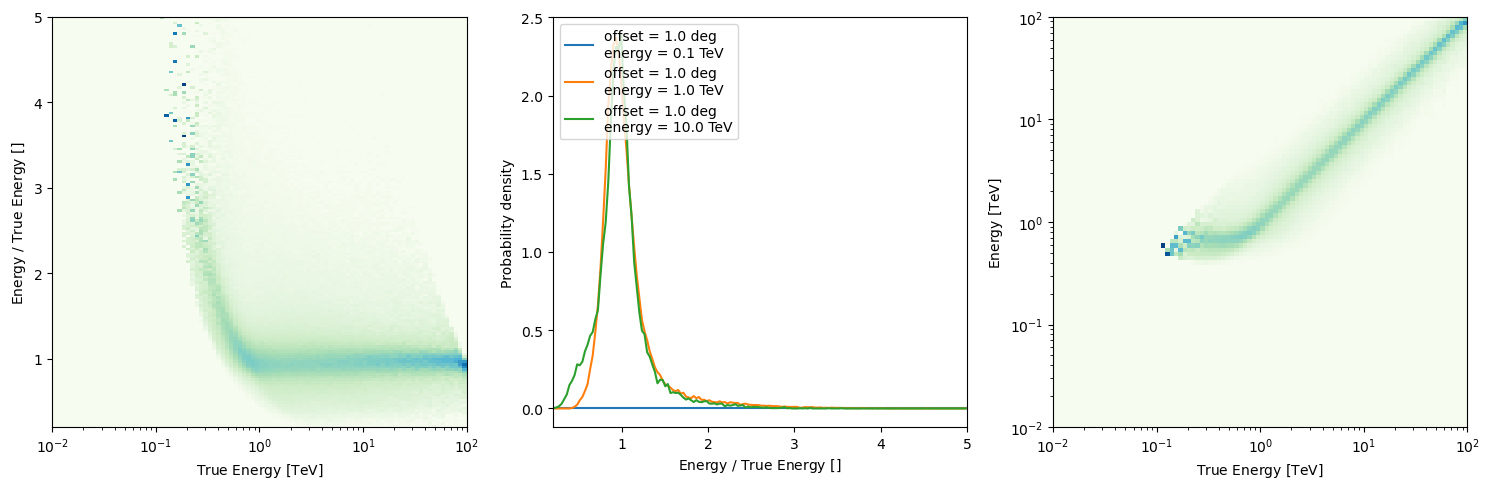

In [9]:
obs.edisp.peek()

- The less dispersion, the better.

This dispersion comes from sampling bias and intrinsic fluctuations of the Cherenkov emission due to fluctuations in the extensive air shower development. Can you explain why we have a plateau at the lowest energies on the right plot?

#### Point spread function

It gives the probability of measuring a direction $p$ when the true direction is $p_{\rm true}$ and the true energy is $E_{\rm true}$.

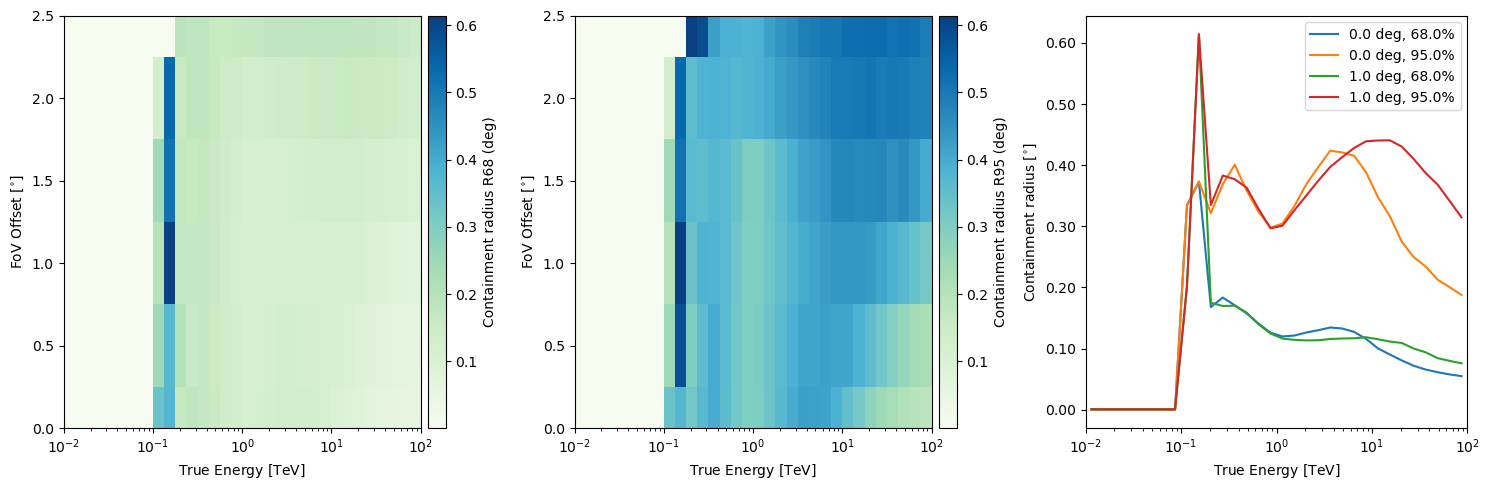

In [10]:
obs.psf.peek()

- The smaller the radius, the better

Our PSF is a few decimal degrees. About half the size of the full Moon ($\sim 0.5 ~\rm deg$)!!

#### Background

It is not really an IRF component, but it is usually included in the DL3 files.

It contains spatial and/or spectral model templates to characterise the irreducible cosmic ray background. Then, these model templates can be used, for example, to model the background of the observations.

Thus, it provides the differential background rate at a certain reconstructed photon energy $E$ and position $p$.

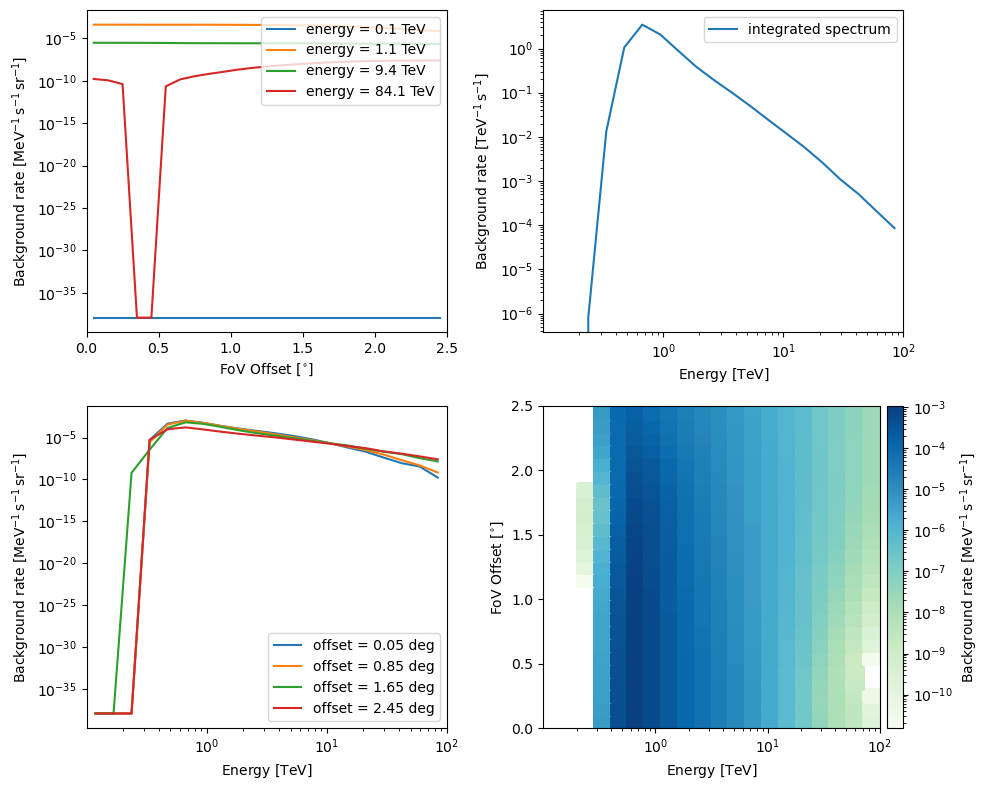

In [11]:
obs.bkg.peek()